<h2>Spam prediction</h2>

<p>Identification of a suitable learning technique for constructing a spam filter and
implement it in Python. Train and evaluate the model. Make a statement about the expected
quality of the filter and make sure that no more than 0.2% of all legitimate emails
are filtered.</p>

<h2>Importing the Libraries</h2>

<p>First, lets import all the libraries needed to perform the project and what will be required in the consequent steps of the process.</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
%matplotlib inline
sns.set_style("darkgrid")
sns.set(font_scale=1.4)

<h2>Load the Dataset</h2>

<p>Now, we load the dataset provided for the project and explore the properties of the dataset, such the the dimention of the data. We know that our feature space is a <b>Bag of Words</b> model representation. Therefore each of our feature represents a <b>word</b> in the <b>document/mail</b>, and the value of that feature represents the <b>number of times</b> that word/feature occured in a particular mail.</p>

In [2]:
mat = scipy.io.loadmat('emails.mat')
X = mat['X'].toarray().T
y = mat['Y'].T.ravel()
print(mat)
print(X.shape)
print(y.shape)
print(y[:10])

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Tue Dec 07 13:57:47 2010', '__version__': '1.0', '__globals__': [], 'X': <57173x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 2351499 stored elements in Compressed Sparse Column format>, 'Y': array([[ 1, -1,  1, ...,  1,  1,  1]], dtype=int16)}
(10000, 57173)
(10000,)
[ 1 -1  1  1  1  1  1  1  1 -1]


In [3]:
labels = np.unique(y, return_counts=True)
print("Percentage of label, ", labels[0][0], ":", np.around(labels[1][0]/(labels[1][0] + labels[1][1])*100, 3))
print("Percentage of label, ", labels[0][1], ":", np.around(labels[1][1]/(labels[1][0] + labels[1][1])*100, 3))

Percentage of label,  -1 : 19.7
Percentage of label,  1 : 80.3


So, we have a dataset consiting of total <i>57173</i> unique words/features and we have a corpus of 10000 emails to use for training and testing purposes of our classifiers.

<h2>Model Selection technique - Triple Cross Validation</h2>
<p>For the purpose of Model selection, we are going to use <b>Triple Cross Validation</b> technique, as this technique works well particularly on large datasets like ours. A typical break down our dataset into the three sets is:</p><br/>
<i><ol>
    <li>Training set (<b>L</b>): 49%</li>
    <li>Cross validation set (<b>T'</b>): 21%</li>
    <li>Test set (<b>T</b>): 30%</li>
</ol></i>

<p>We will be using Scikit learn module <code>train_test_split</code> to split the data for this purpose. As, this module splits the data into 2 parts only, we will atfirst split the data in <i>70%-30%</i> ratio. Then we will split the <i>70%</i> sized data again into <i>70%-30%</i> split, which will create a Triple split of <i>49%-21%-30%</i></p>

In [4]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

X_train_union, X_test, y_train_union, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0, stratify=y)
X_train, X_cv, y_train, y_cv = train_test_split(X_train_union, y_train_union, test_size=0.3, random_state=0, stratify=y_train_union)

<h2>Hyperparameter Tuning and Predictive Analysis</h2>
<p>The prediction of spam mail is a classification problem. The classifiers that can be used for this comparison purpose are mentioned below</p>
<i><ol>
    <li>Multinomial Naive Bayes</li>
    <li>Support Vector Machines with Gaussian Kernel</li>
    <li>Random Forest</li>
    <li>Decision Tree</li>
    <li>Logistic Regression</li>
</ol></i>

<p>Our crucial assumption for selection is that, it is much worse to misclassify non-spam than misclassify an spam. Our Threshold hor <b>False Positive Rate</b> can not be more than <b>0.2%</b></p>

<h3><font color=grey>Multinomial naive bayes classifier</font></h3>
<p>We train different Bayes Models changing values of the regularization parameter <b>&#x03B1;</b>. Then we evaluate each model prediction using Accuracy Score and Confusion Matrix parameters.</p>

In [5]:
from sklearn.naive_bayes import MultinomialNB

list_alpha = np.arange(1/100000, 20, 0.11)
score_train = np.zeros(len(list_alpha))
score_test = np.zeros(len(list_alpha))
recall_score = np.zeros(len(list_alpha))
precision_score = np.zeros(len(list_alpha))
fpr_score = np.zeros(len(list_alpha))
f1_score = np.zeros(len(list_alpha))
confusion_matrix = []

i = 0
for alpha in list_alpha:
    bayes = MultinomialNB(alpha=alpha)
    bayes.fit(X_train, y_train)
    pred = bayes.predict(X_cv)
    
    score_train[i] = bayes.score(X_train, y_train)
    score_test[i] = metrics.accuracy_score(y_cv, pred)
    recall_score[i] = metrics.recall_score(y_cv, pred)
    precision_score[i] = metrics.precision_score(y_cv, pred)
    confusion_matrix.append(metrics.confusion_matrix(y_cv, pred))
    
    tn, fp, fn, tp = confusion_matrix[i].ravel()
    fpr_score[i] = fp/(fp + tn)
    f1_score[i] = metrics.f1_score(y_cv, pred)
    i = i + 1 

<h5>Now we visualize the metrics of the prediction models</h5>

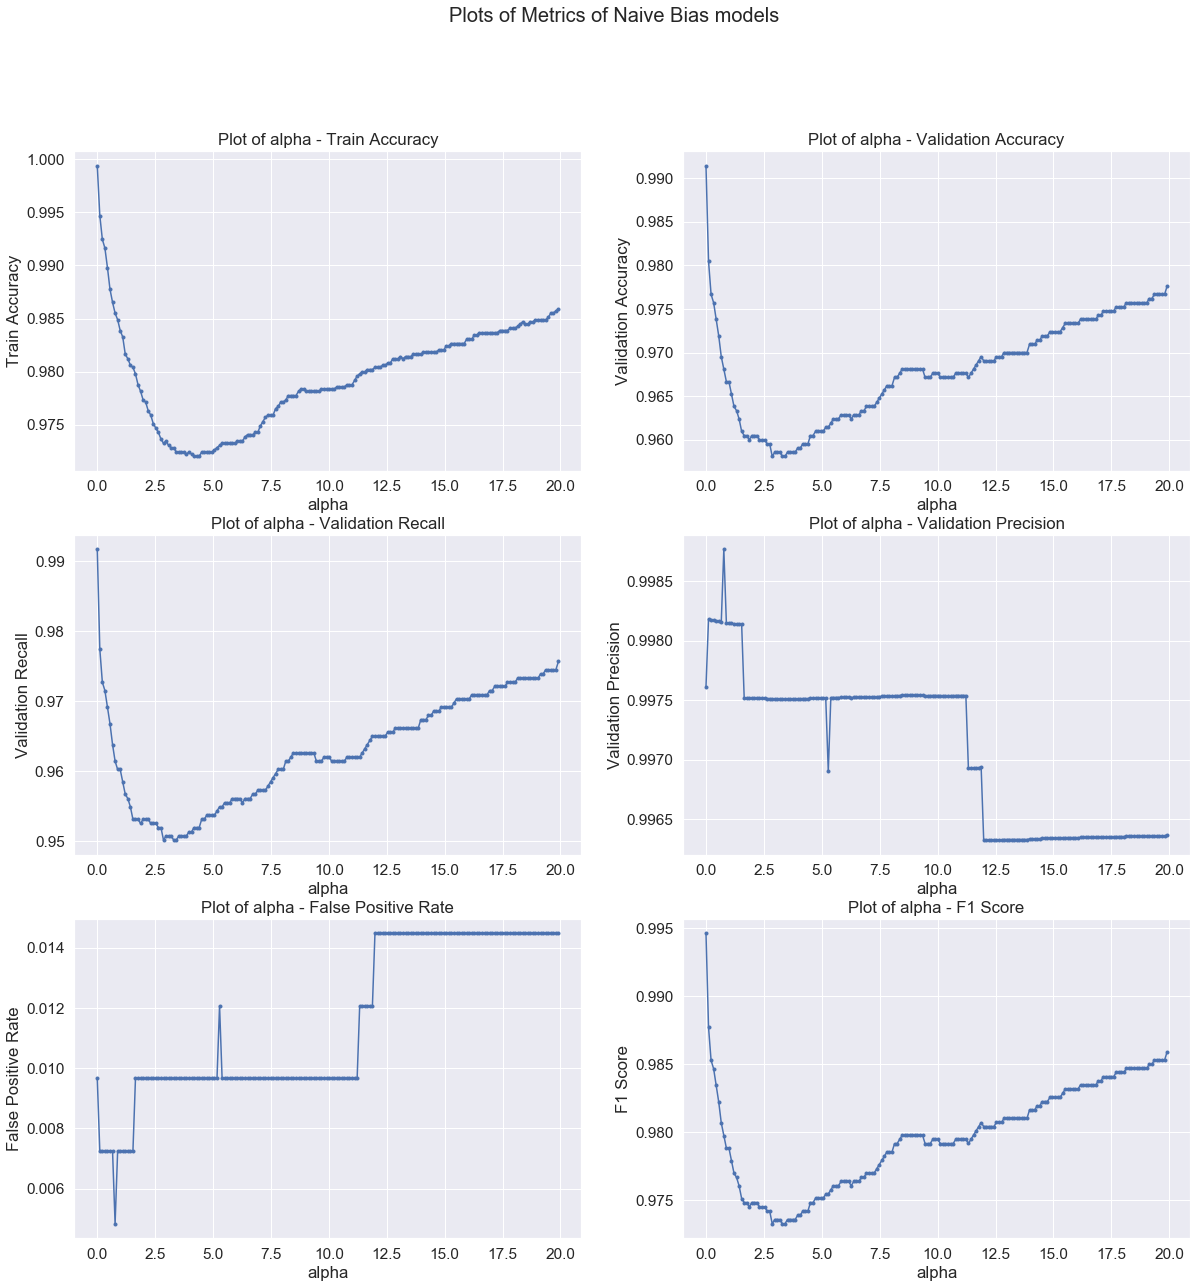

In [6]:
matrix = np.matrix(np.c_[list_alpha, score_train, score_test, recall_score, precision_score, fpr_score, f1_score])
models_df = pd.DataFrame(data = matrix, columns = 
                      ['alpha', 'Train Accuracy', 'Validation Accuracy', 'Validation Recall', 'Validation Precision', 'False Positive Rate', 'F1 Score'])
models_df['Confusion Matrix'] = confusion_matrix
models_df.head()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,20))
fig.suptitle('Plots of Metrics of Naive Bias models', fontsize=20)

i = 1
cols = models_df.columns
for ax in axes.flatten():
    ax.plot(models_df['alpha'], models_df[cols[i]], marker='.')
    ax.set(title='Plot of alpha - '+cols[i], xlabel='alpha', ylabel=cols[i])
    i = i + 1

<h5>Plots Analysis and Choosing the best fit for Naive Bias model</h5>
<p>As we can see from the graphs, we get the lowest False Positive Rate below 0.6% as well as best Precision for the low lange of the Regularizer, &#x03B1; Also we get a nice Test Accuracy score at that range. So, we pick now the single value &#x03B1; corresponding to the lowest FPR and Highest Test Accuracy among those lowest FPR &#x03B1; as the best fit for our Model, trading off a little Accuracy for better Precision as that is the most important criteria for our selection.</p>

The Naive Bias model with the best fit is:
alpha                   0.770010
Train Accuracy          0.985510
Validation Accuracy     0.968095
Validation Recall       0.961447
Validation Precision    0.998768
False Positive Rate     0.004831
F1 Score                0.979752
Name: 7, dtype: float64


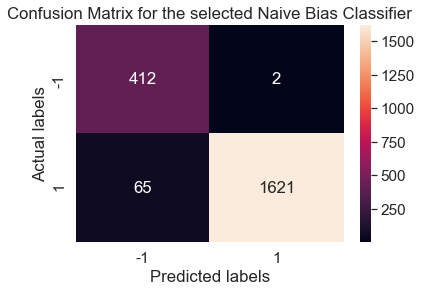

In [7]:
#Find all the models with the minimum FPR
best_index = models_df['False Positive Rate'].idxmin()
min_fpr = models_df.iloc[best_index, :]['False Positive Rate']

#Find the model having the maximum Test Accuracy among previously found models
min_fpr_df = models_df[models_df['False Positive Rate'] == min_fpr]
best_index = min_fpr_df['Validation Accuracy'].idxmax()

cm_nb = models_df.iloc[best_index, :]['Confusion Matrix']
models_df.drop(columns=['Confusion Matrix'], inplace=True)

best_model_nb = models_df.iloc[best_index, :]
print('The Naive Bias model with the best fit is:')
print(best_model_nb)

ax= plt.subplot()
sns.heatmap(cm_nb, annot=True, ax = ax, fmt='g')

# labels, title and ticks
ax.set(title='Confusion Matrix for the selected Naive Bias Classifier', xlabel='Predicted labels', ylabel='Actual labels')
ax.xaxis.set_ticklabels(['-1', '1']); ax.yaxis.set_ticklabels(['-1', '1']);

<h3><font color=grey>Support Vector Machine classifier</font></h3>
<p>We are going to apply the same reasoning applying the support vector machine model with the Gaussian kernel. We train different models changing the parameter <b>C</b> of the Model. We evaluate the accuracy, recall and precision of the model with the test set.</p>

In [8]:
from sklearn import svm
import time

list_C = np.arange(300, 610, 10)
score_train = np.zeros(len(list_C))
score_test = np.zeros(len(list_C))
recall_score = np.zeros(len(list_C))
precision_score = np.zeros(len(list_C))
fpr_score = np.zeros(len(list_C))
f1_score = np.zeros(len(list_C))
confusion_matrix = []

i = 0
for C in list_C:
    start = time.time()
    svc = svm.SVC(C=C, gamma='auto', random_state=0)
    svc.fit(X_train, y_train)
    pred = svc.predict(X_cv)
    
    score_train[i] = svc.score(X_train, y_train)
    score_test[i] = metrics.accuracy_score(y_cv, pred)
    recall_score[i] = metrics.recall_score(y_cv, pred)
    precision_score[i] = metrics.precision_score(y_cv, pred)
    confusion_matrix.append(metrics.confusion_matrix(y_cv, pred))
    
    end = time.time()
    #print('Trained for C parameter:', C, ', Time taken:',end - start,'sec')
    
    tn, fp, fn, tp = confusion_matrix[i].ravel()
    fpr_score[i] = fp/(fp + tn)
    f1_score[i] = metrics.f1_score(y_cv, pred)
    
    i = i+1

<h5>Visualization of the metrics of the SVM prediction models</h5>

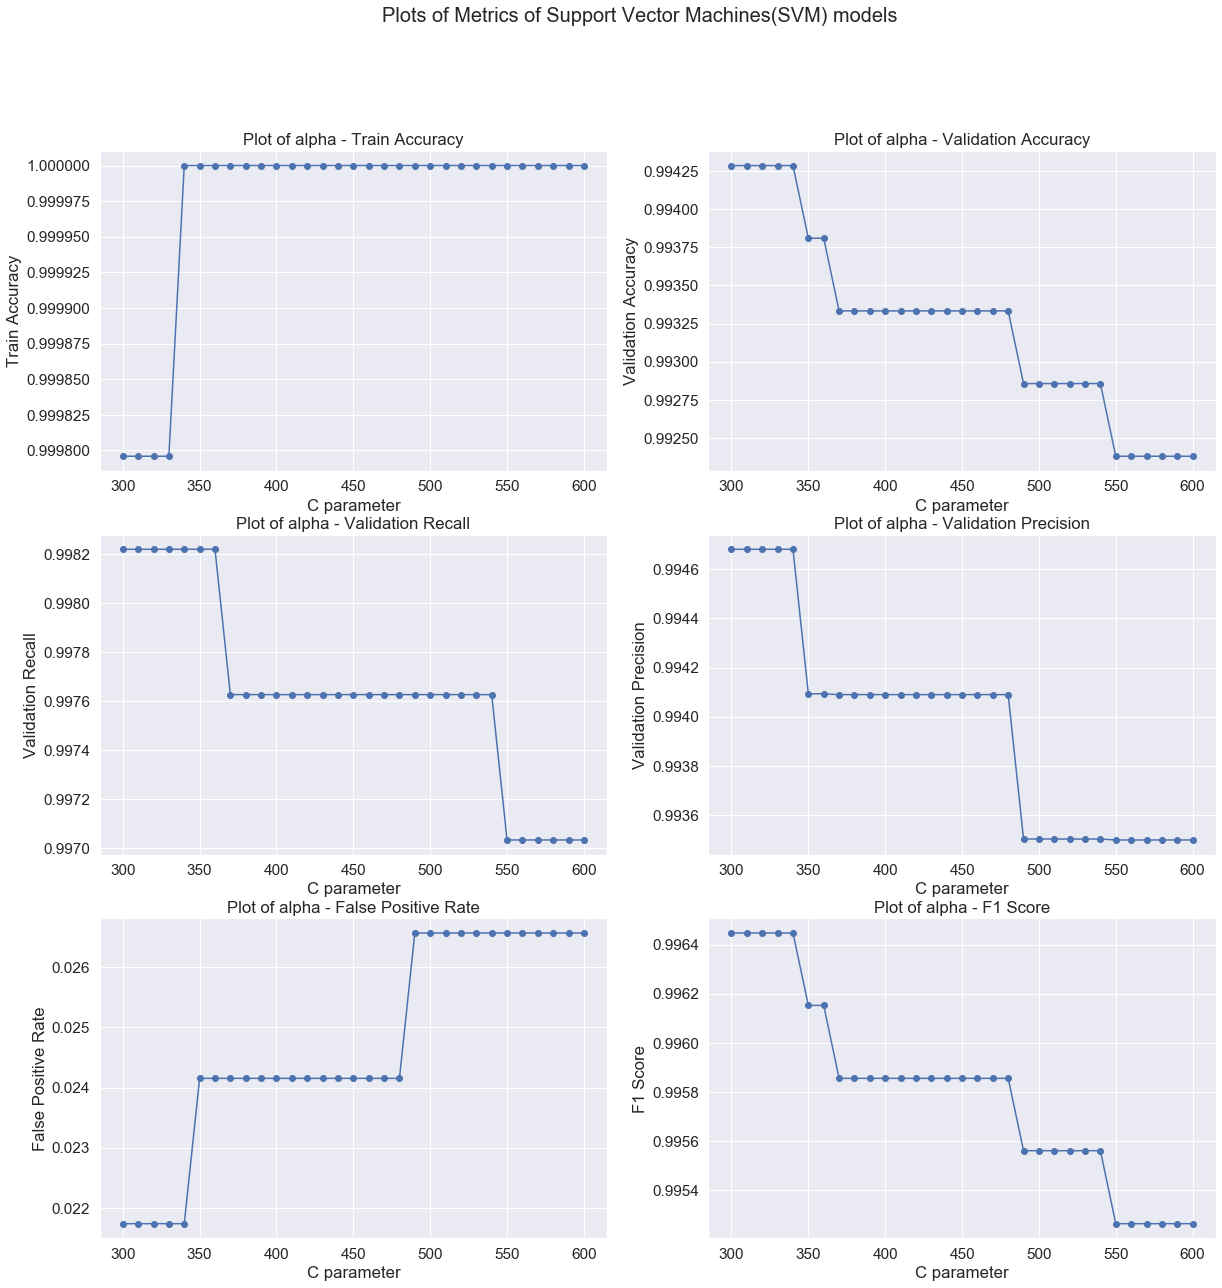

In [9]:
matrix = np.matrix(np.c_[list_C, score_train, score_test, recall_score, precision_score, fpr_score, f1_score])
models_df = pd.DataFrame(data = matrix, columns = 
                      ['C-value', 'Train Accuracy', 'Validation Accuracy', 'Validation Recall', 'Validation Precision', 'False Positive Rate', 'F1 Score'])
models_df['Confusion Matrix'] = confusion_matrix
models_df.head()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,20))
fig.suptitle('Plots of Metrics of Support Vector Machines(SVM) models', fontsize=20)

i = 1
cols = models_df.columns
for ax in axes.flatten():
    ax.plot(models_df['C-value'], models_df[cols[i]], marker='o')
    ax.set(title='Plot of alpha - '+cols[i], xlabel='C parameter', ylabel=cols[i])
    i = i + 1

<h5>Plots Analysis and Choosing the best fit for SVM</h5>
<p>In this case as we see, we get the lowest False Positive Rate around 2.2% as well as best Precision and Test Accuracy at a value of <i>300</i> of the parameter, C. This FPR is over our necessary Threshold level of 0.2%. We now find the details of our best model for comparison purpose with other choice of classifiers.</p>

The SVM model with the best fit is:
C-value                 300.000000
Train Accuracy            0.999796
Validation Accuracy       0.994286
Validation Recall         0.998221
Validation Precision      0.994681
False Positive Rate       0.021739
F1 Score                  0.996448
Name: 0, dtype: float64


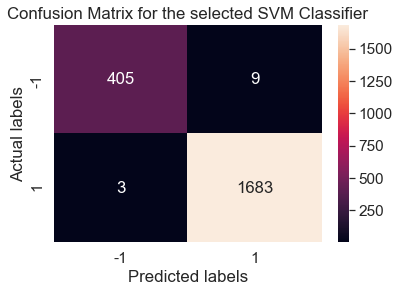

In [10]:
#Find all the models with the minimum FPR
best_index = models_df['False Positive Rate'].idxmin()
min_fpr = models_df.iloc[best_index, :]['False Positive Rate']

#Find the model having the maximum Test Accuracy among previously found models
min_fpr_df = models_df[models_df['False Positive Rate'] == min_fpr]
best_index = min_fpr_df['Validation Accuracy'].idxmax()

cm_svm = models_df.iloc[best_index, :]['Confusion Matrix']
models_df.drop(columns=['Confusion Matrix'], inplace=True)

best_model_svm = models_df.iloc[best_index, :]
print('The SVM model with the best fit is:')
print(best_model_svm)

ax= plt.subplot()
sns.heatmap(cm_svm, annot=True, ax = ax, fmt='g')

# labels, title and ticks
ax.set(title='Confusion Matrix for the selected SVM Classifier', xlabel='Predicted labels', ylabel='Actual labels')
ax.xaxis.set_ticklabels(['-1', '1']); ax.yaxis.set_ticklabels(['-1', '1']);

<h3><font color=grey>Random Forest classifier</font></h3>
<p>Now we run our analysis using Random Forest Classifier. We train different models by changing the number of tress of the Model. We evaluate the accuracy, recall and precision of the model with the test set.</p>

In [11]:
from sklearn.ensemble import RandomForestClassifier

list_tree = np.arange(10, 210, 10)
score_train = np.zeros(len(list_tree))
score_test = np.zeros(len(list_tree))
recall_score = np.zeros(len(list_tree))
precision_score = np.zeros(len(list_tree))
fpr_score = np.zeros(len(list_tree))
f1_score = np.zeros(len(list_tree))
confusion_matrix = []

i = 0
for n_tree in list_tree:
    rf = RandomForestClassifier(n_estimators=n_tree, n_jobs=2, random_state=0)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_cv)
    
    score_train[i] = rf.score(X_train, y_train)
    score_test[i]= metrics.accuracy_score(y_cv, pred)
    recall_score[i] = metrics.recall_score(y_cv, pred)
    precision_score[i] = metrics.precision_score(y_cv, pred)
    confusion_matrix.append(metrics.confusion_matrix(y_cv, pred))
    
    #print('Trained for tree count:', n_tree)
    
    tn, fp, fn, tp = confusion_matrix[i].ravel()
    fpr_score[i] = fp/(fp + tn)
    f1_score[i] = metrics.f1_score(y_cv, pred)
    
    i = i+1

<h5>Visualization of the metrics of the Random Forest prediction models</h5>

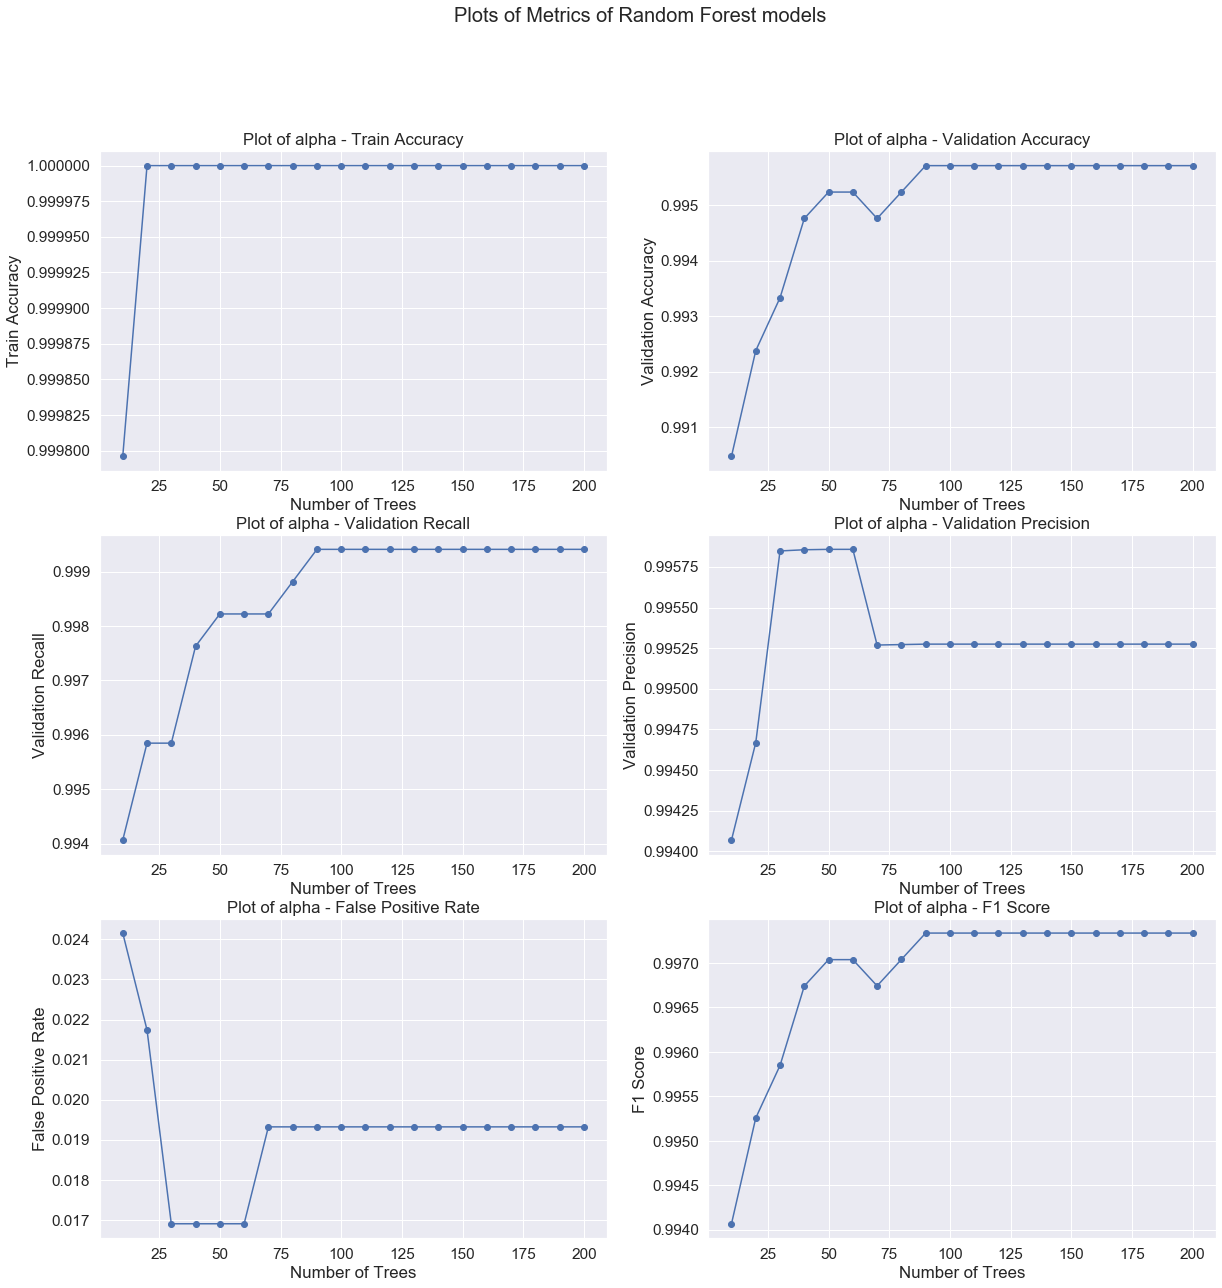

In [12]:
matrix = np.matrix(np.c_[list_tree, score_train, score_test, recall_score, precision_score, fpr_score, f1_score])
models_df = pd.DataFrame(data = matrix, columns = 
                      ['n_tree', 'Train Accuracy', 'Validation Accuracy', 'Validation Recall', 'Validation Precision', 'False Positive Rate', 'F1 Score'])
models_df['Confusion Matrix'] = confusion_matrix
models_df.head()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,20))
fig.suptitle('Plots of Metrics of Random Forest models', fontsize=20)

i = 1
cols = models_df.columns
for ax in axes.flatten():
    ax.plot(models_df['n_tree'], models_df[cols[i]], marker='o')
    ax.set(title='Plot of alpha - '+cols[i], xlabel='Number of Trees', ylabel=cols[i])
    i = i + 1

<h5>Plots Analysis and Choosing the best fit for Random Forest</h5>
<p>In this case as we see, we get the lowest False Positive Rate around 1.7% as well as best Precision when the number of trees used is around <i>30</i> to <i>60</i>. The Test Accuracy is a bit low compared to the higher number of tress, as usually in case of Random Forest algorithm, accuracy improves with greater number of trees. This FPR is also over our necessary Threshold level of 0.2%. We now find the details of our best model for comparison purpose with other choice of classifiers.</p>

The Random Forest model with the best fit is:
n_tree                  50.000000
Train Accuracy           1.000000
Validation Accuracy      0.995238
Validation Recall        0.998221
Validation Precision     0.995858
False Positive Rate      0.016908
F1 Score                 0.997038
Name: 4, dtype: float64


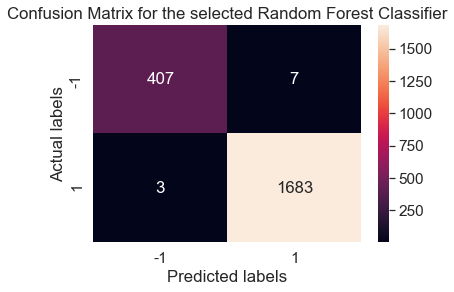

In [13]:
#Find all the models with the minimum FPR
best_index = models_df['False Positive Rate'].idxmin()
min_fpr = models_df.iloc[best_index, :]['False Positive Rate']

#Find the model having the maximum Test Accuracy among previously found models
min_fpr_df = models_df[models_df['False Positive Rate'] == min_fpr]
best_index = min_fpr_df['Validation Accuracy'].idxmax()

cm_rf = models_df.iloc[best_index, :]['Confusion Matrix']
models_df.drop(columns=['Confusion Matrix'], inplace=True)

best_model_rf = models_df.iloc[best_index, :]
print('The Random Forest model with the best fit is:')
print(best_model_rf)

ax= plt.subplot()
sns.heatmap(cm_rf, annot=True, ax = ax, fmt='g')

# labels, title and ticks
ax.set(title='Confusion Matrix for the selected Random Forest Classifier', xlabel='Predicted labels', ylabel='Actual labels')
ax.xaxis.set_ticklabels(['-1', '1']); ax.yaxis.set_ticklabels(['-1', '1']);

<h3><font color=grey>Decision Tree classifier</font></h3>
<p>Now we train different Decision Tree Models changing values of the parameter <i>min_samples_split</i>, which is The minimum number of samples required to split an internal node. Then we evaluate each model prediction using Accuracy Score and Confusion Matrix parameters.</p>

In [14]:
from sklearn.tree import DecisionTreeClassifier

list_split = np.arange(10,210,10)
score_train = np.zeros(len(list_split))
score_test = np.zeros(len(list_split))
recall_score = np.zeros(len(list_split))
precision_score = np.zeros(len(list_split))
fpr_score = np.zeros(len(list_split))
f1_score = np.zeros(len(list_split))
confusion_matrix = []

i = 0
for n_split in list_split:
    dt_clf = DecisionTreeClassifier(min_samples_split=n_split, random_state=0)
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_cv)
    
    score_train[i] = dt_clf.score(X_train, y_train)
    score_test[i]= metrics.accuracy_score(y_cv, pred)
    recall_score[i] = metrics.recall_score(y_cv, pred)
    precision_score[i] = metrics.precision_score(y_cv, pred)
    confusion_matrix.append(metrics.confusion_matrix(y_cv, pred))
    
    #print('Trained for minimum split count:', n_split)
    
    tn, fp, fn, tp = confusion_matrix[i].ravel()
    fpr_score[i] = fp/(fp + tn)
    f1_score[i] = metrics.f1_score(y_cv, pred)
    
    i = i+1


<h5>Visualization of the metrics of the Decision Tree prediction models</h5>

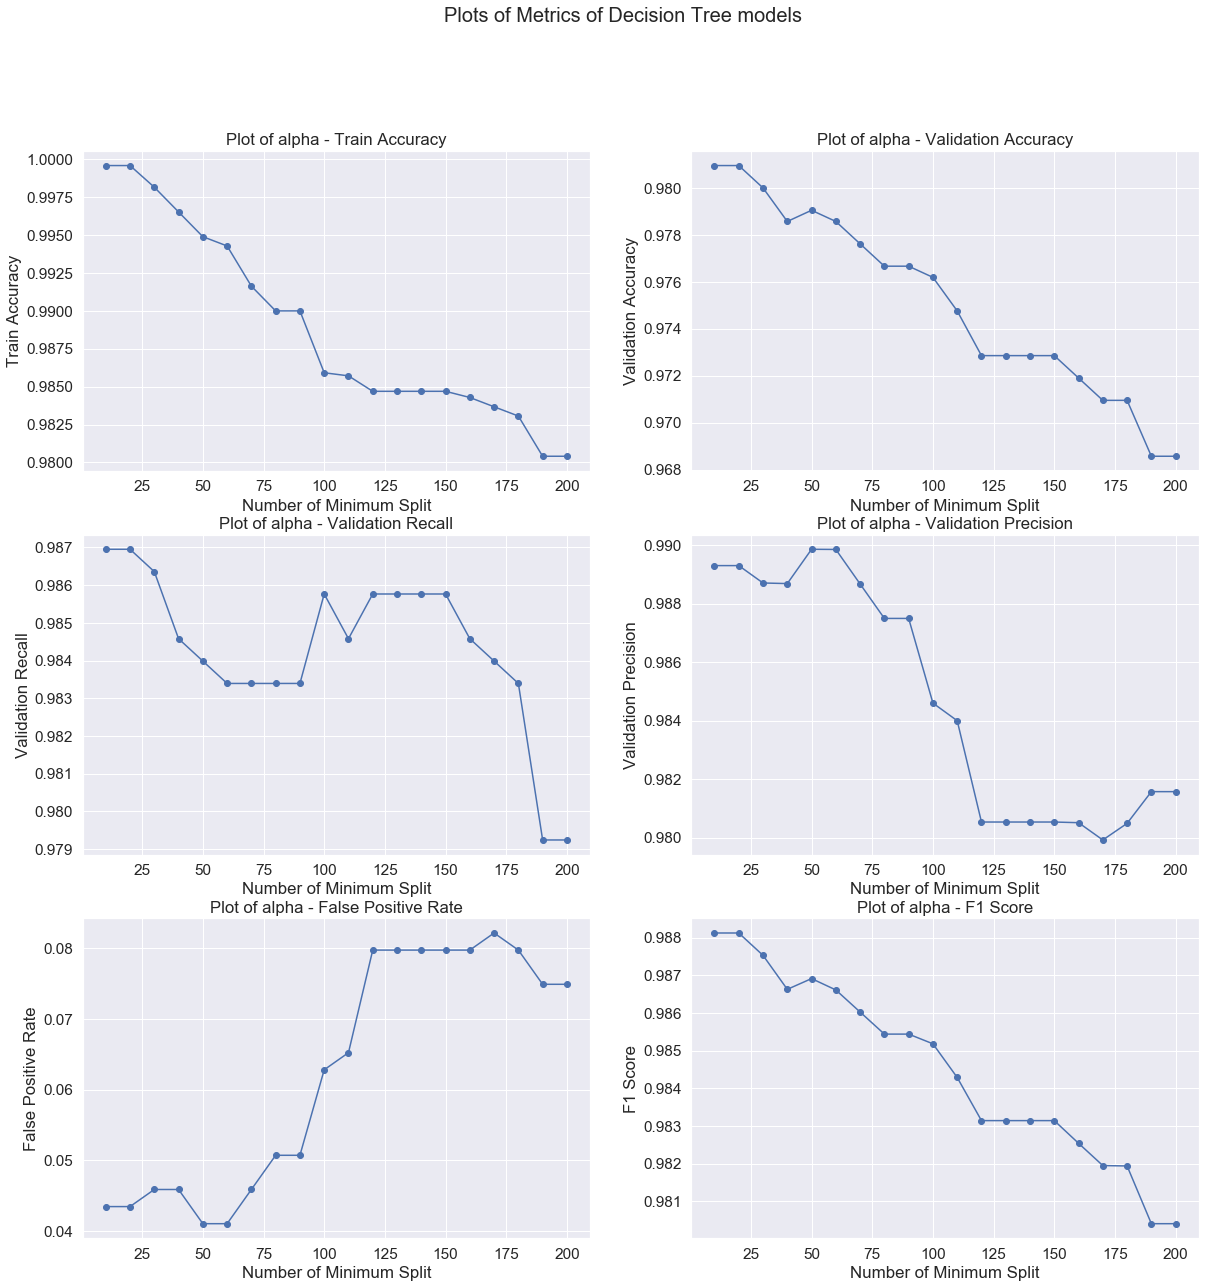

In [15]:
matrix = np.matrix(np.c_[list_split, score_train, score_test, recall_score, precision_score, fpr_score, f1_score])
models_df = pd.DataFrame(data = matrix, columns = 
                      ['n_min_split', 'Train Accuracy', 'Validation Accuracy', 'Validation Recall', 'Validation Precision', 'False Positive Rate', 'F1 Score'])
models_df['Confusion Matrix'] = confusion_matrix
models_df.head()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,20))
fig.suptitle('Plots of Metrics of Decision Tree models', fontsize=20)

i = 1
cols = models_df.columns
for ax in axes.flatten():
    ax.plot(models_df['n_min_split'], models_df[cols[i]], marker='o')
    ax.set(title='Plot of alpha - '+cols[i], xlabel='Number of Minimum Split', ylabel=cols[i])
    i = i + 1

<h5>Plots Analysis and Choosing the best fit for Decision Tree</h5>
<p>In this case as we see, we get the lowest False Positive Rate around 4% as well as best Precision when the number of minimum sample split used is <i>40</i>. The Test Accuracy is a also high for this split choice. But this FPR is also over our necessary Threshold level of 0.2%. We now find the details of our best model for comparison purpose with other choice of classifiers.</p>

The Decision Tree model with the best fit is:
n_min_split             50.000000
Train Accuracy           0.994898
Validation Accuracy      0.979048
Validation Recall        0.983986
Validation Precision     0.989857
False Positive Rate      0.041063
F1 Score                 0.986913
Name: 4, dtype: float64


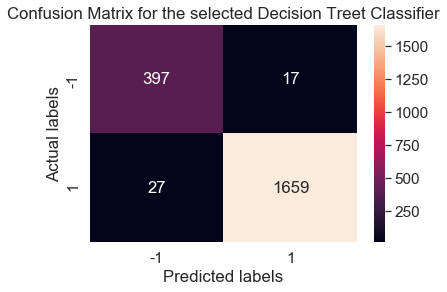

In [16]:
#Find all the models with the minimum FPR
best_index = models_df['False Positive Rate'].idxmin()
min_fpr = models_df.iloc[best_index, :]['False Positive Rate']

#Find the model having the maximum Test Accuracy among previously found models
min_fpr_df = models_df[models_df['False Positive Rate'] == min_fpr]
best_index = min_fpr_df['Validation Accuracy'].idxmax()

cm_dt = models_df.iloc[best_index, :]['Confusion Matrix']
models_df.drop(columns=['Confusion Matrix'], inplace=True)

best_model_dt = models_df.iloc[best_index, :]
print('The Decision Tree model with the best fit is:')
print(best_model_dt)

ax= plt.subplot()
sns.heatmap(cm_dt, annot=True, ax = ax, fmt='g')

# labels, title and ticks
ax.set(title='Confusion Matrix for the selected Decision Treet Classifier', xlabel='Predicted labels', ylabel='Actual labels')
ax.xaxis.set_ticklabels(['-1', '1']); ax.yaxis.set_ticklabels(['-1', '1']);

<h3><font color=grey>Logistic Regression classifier</font></h3>
<p>Next we train different Logistic Regression Models changing values of the parameter <i>C</i>, which is inverse of regularization strength. Like in support vector machines, smaller values specify stronger regularization. Then we evaluate each model prediction using Accuracy Score and Confusion Matrix parameters.</p>

In [17]:
from sklearn.linear_model import LogisticRegression

list_C = np.arange(1, 610, 10)
score_train = np.zeros(len(list_C))
score_test = np.zeros(len(list_C))
recall_score = np.zeros(len(list_C))
precision_score = np.zeros(len(list_C))
fpr_score = np.zeros(len(list_C))
f1_score = np.zeros(len(list_C))
confusion_matrix = []

i = 0
for C in list_C:
    logreg_clf = LogisticRegression(solver='liblinear', penalty='l1', C=C, random_state=0)
    logreg_clf.fit(X_train, y_train)
    pred = logreg_clf.predict(X_cv)
    
    score_train[i] = logreg_clf.score(X_train, y_train)
    score_test[i]= metrics.accuracy_score(y_cv, pred)
    recall_score[i] = metrics.recall_score(y_cv, pred)
    precision_score[i] = metrics.precision_score(y_cv, pred)
    confusion_matrix.append(metrics.confusion_matrix(y_cv, pred))
    
    #print('Trained for C parameter:', C)
    
    tn, fp, fn, tp = confusion_matrix[i].ravel()
    fpr_score[i] = fp/(fp + tn)
    f1_score[i] = metrics.f1_score(y_cv, pred)
    
    i = i+1

<h5>Visualization of the metrics of the Logistic Regression prediction models</h5>

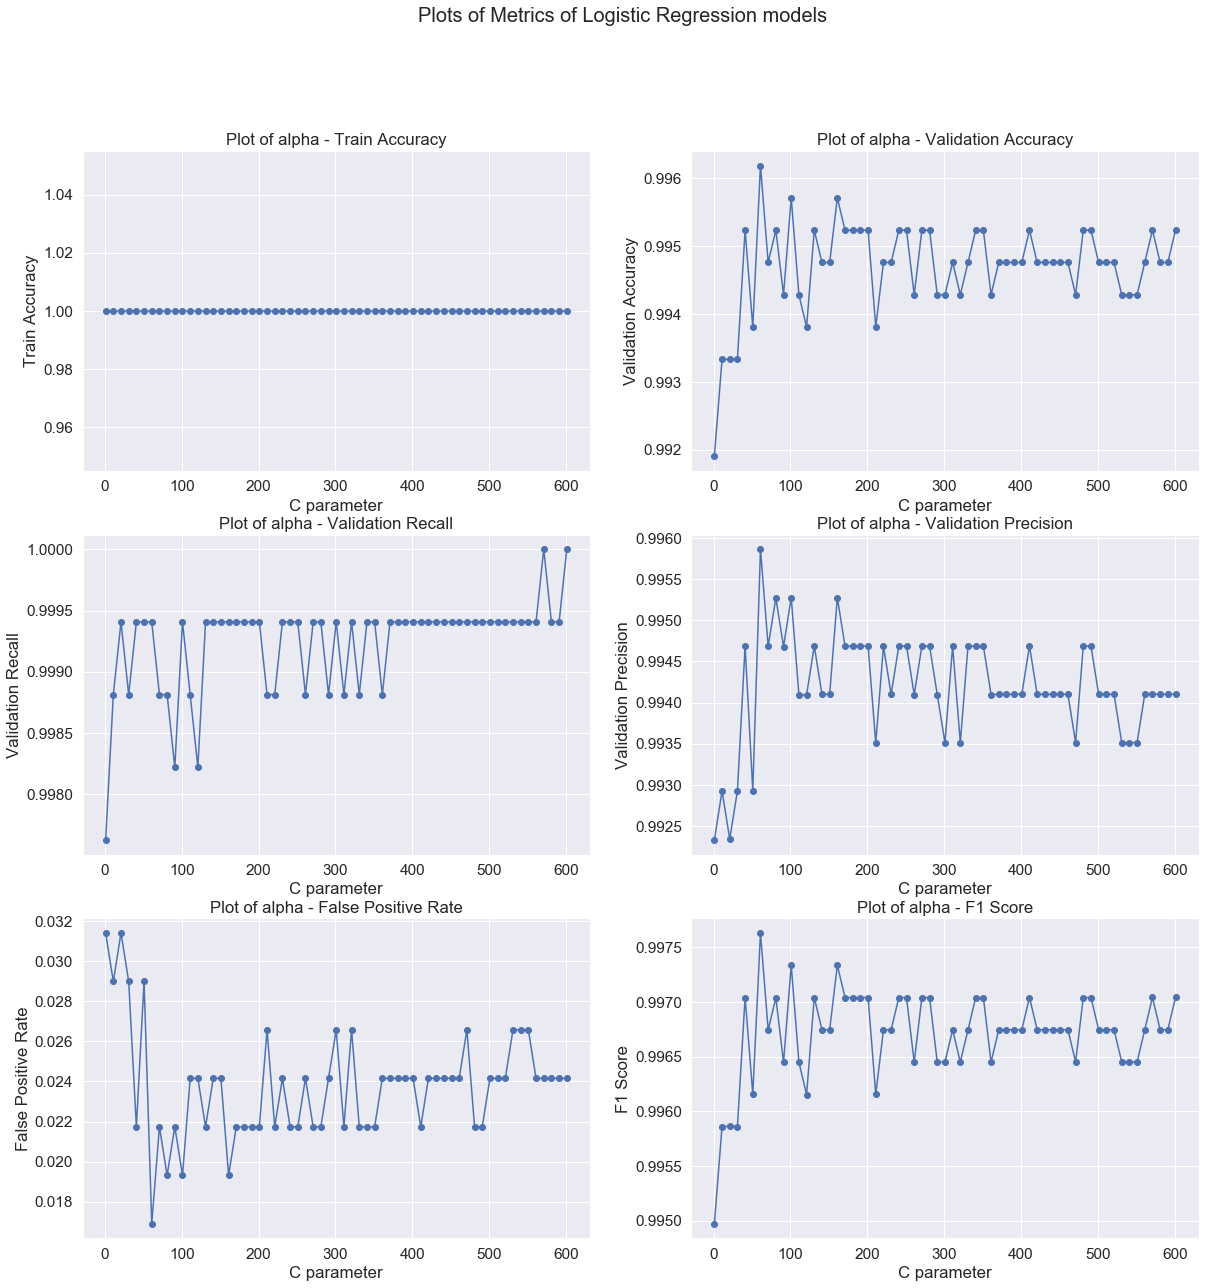

In [18]:
matrix = np.matrix(np.c_[list_C, score_train, score_test, recall_score, precision_score, fpr_score, f1_score])
models_df = pd.DataFrame(data = matrix, columns = 
                      ['C-value', 'Train Accuracy', 'Validation Accuracy', 'Validation Recall', 'Validation Precision', 'False Positive Rate', 'F1 Score'])
models_df['Confusion Matrix'] = confusion_matrix
models_df.head()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20,20))
fig.suptitle('Plots of Metrics of Logistic Regression models', fontsize=20)

i = 1
cols = models_df.columns
for ax in axes.flatten():
    ax.plot(models_df['C-value'], models_df[cols[i]], marker='o')
    ax.set(title='Plot of alpha - '+cols[i], xlabel='C parameter', ylabel=cols[i])
    i = i + 1

<h5>Plots Analysis and Choosing the best fit for Logistic Regression</h5>
<p>In this case as we see, we get the lowest False Positive Rate around 1.8% as well as best Precision and Test Accuracy at a value of little over <i>500</i> of the parameter, C. This FPR is also over our necessary Threshold level of 0.2%, but performs better than on our dataset than other type of Classifiers except Naive Bias. We now find the details of our best model for comparison purpose with other choice of classifiers.</p>

The Logistic Regression model with the best fit is:
C-value                 61.000000
Train Accuracy           1.000000
Validation Accuracy      0.996190
Validation Recall        0.999407
Validation Precision     0.995863
False Positive Rate      0.016908
F1 Score                 0.997632
Name: 6, dtype: float64


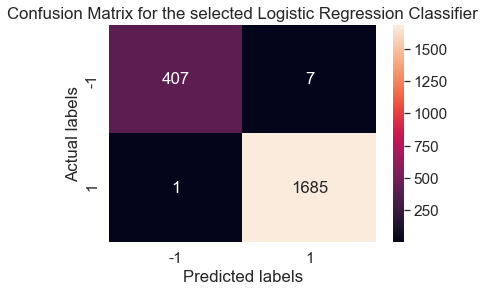

In [19]:
#Find all the models with the minimum FPR
best_index = models_df['False Positive Rate'].idxmin()
min_fpr = models_df.iloc[best_index, :]['False Positive Rate']

#Find the model having the maximum Test Accuracy among previously found models
min_fpr_df = models_df[models_df['False Positive Rate'] == min_fpr]
best_index = min_fpr_df['Validation Accuracy'].idxmax()

cm_lr = models_df.iloc[best_index, :]['Confusion Matrix']
models_df.drop(columns=['Confusion Matrix'], inplace=True)

best_model_lr = models_df.iloc[best_index, :]
print('The Logistic Regression model with the best fit is:')
print(best_model_lr)

ax= plt.subplot()
sns.heatmap(cm_lr, annot=True, ax = ax, fmt='g')

# labels, title and ticks
ax.set(title='Confusion Matrix for the selected Logistic Regression Classifier', xlabel='Predicted labels', ylabel='Actual labels')
ax.xaxis.set_ticklabels(['-1', '1']); ax.yaxis.set_ticklabels(['-1', '1']);

<h2>Result of Hyperparameter Tuning</h2>
<p>After we have computed the best Hyperparameters of all the models using the <b>Validation Dataset</b>, we have now the selected Models with each classifiers. The results are shown below</p>

In [20]:
param_df = pd.concat([best_model_nb, best_model_svm, best_model_rf, best_model_dt, best_model_lr], axis=1, sort=True)
param_df.columns = ['Naive Bias', 'SVM', 'Random Forest', 'Decision Tree', 'Logistic Regression']
param_df

,Naive Bias,SVM,Random Forest,Decision Tree,Logistic Regression
C-value,NaN,300.000000,NaN,NaN,61.000000
F1 Score,0.979752,0.996448,0.997038,0.986913,0.997632
False Positive Rate,0.004831,0.021739,0.016908,0.041063,0.016908
Train Accuracy,0.985510,0.999796,1.000000,0.994898,1.000000
Validation Accuracy,0.968095,0.994286,0.995238,0.979048,0.996190
Validation Precision,0.998768,0.994681,0.995858,0.989857,0.995863
Validation Recall,0.961447,0.998221,0.998221,0.983986,0.999407
alpha,0.770010,NaN,NaN,NaN,NaN
n_min_split,NaN,NaN,NaN,50.000000,NaN
n_tree,NaN,NaN,50.000000,NaN,NaN


In [21]:
print('Naive Bias classifier has produced the best false positive rate among all')
print(best_model_nb)

Naive Bias classifier has produced the best false positive rate among all
alpha                   0.770010
Train Accuracy          0.985510
Validation Accuracy     0.968095
Validation Recall       0.961447
Validation Precision    0.998768
False Positive Rate     0.004831
F1 Score                0.979752
Name: 7, dtype: float64


<h5>Training of Model on Union of Training and Tuning Instances</h5>
<p>Now we train different kind of selected classifiers over (<b>L &#8746; T'</b>) which is the union of training and validation set and make the prediction over the Test set, <b>T</b> to calculate comparing training & test <i>Accuracy scores, False Positive Rate(FPR), Precision, Recall score</i> according to the <b>Triple Cross Validation</b> technique.</p>

In [22]:
model_nb = MultinomialNB(alpha=best_model_nb['alpha'])
model_svm = svm.SVC(C=300, gamma='auto', random_state=0)
model_rf = RandomForestClassifier(n_estimators=120, n_jobs=2, random_state=0)
model_dt = DecisionTreeClassifier(min_samples_split=20, random_state=0)
model_lr = LogisticRegression(solver='liblinear', penalty='l1', C=31, random_state=0)

#Training
model_nb.fit(X_train_union, y_train_union)
model_svm.fit(X_train_union, y_train_union)
model_rf.fit(X_train_union, y_train_union)
model_dt.fit(X_train_union, y_train_union)
model_lr.fit(X_train_union, y_train_union)

#Prediction over the unseen mails for Spam
pred_nb = model_nb.predict(X_test)
pred_svm = model_svm.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_dt = model_dt.predict(X_test)
pred_lr = model_lr.predict(X_test)


In [23]:
model_nb = MultinomialNB(alpha=best_model_nb['alpha'])
model_nb.fit(X_train_union, y_train_union)
pred_nb = model_nb.predict(X_test)

<h2>Result Analysis</h2>
<p>After we have computed the predictions from all The classifiers used, we can analyze the results to find the performance of each of our models. We do that by comparing training & test <i>Accuracy scores, False Positive Rate(FPR), Precision, Recall score</i>. In the end we plot <i>ROC curve</i> to view the charactersitic of the model.</p>
<p>The final output metrics of different classifiers after finding the best parameter is shown below.</p>

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#Check the accuracy score
score_nb = metrics.accuracy_score(y_test, pred_nb)
score_svm = metrics.accuracy_score(y_test, pred_svm)
score_rf = metrics.accuracy_score(y_test, pred_rf)
score_dt = metrics.accuracy_score(y_test, pred_dt)
score_lr = metrics.accuracy_score(y_test, pred_lr)

tn_1, fp_1, fn_1, tp_1 = confusion_matrix(y_test, pred_nb).ravel()
tn_2, fp_2, fn_2, tp_2 = confusion_matrix(y_test, pred_svm).ravel()
tn_3, fp_3, fn_3, tp_3 = confusion_matrix(y_test, pred_rf).ravel()
tn_4, fp_4, fn_4, tp_4 = confusion_matrix(y_test, pred_dt).ravel()
tn_5, fp_5, fn_5, tp_5 = confusion_matrix(y_test, pred_lr).ravel()

columns = ['Model', 'Test Accuracy', 'False Positive Rate (FPR)%', 'Precision Score', 'Recall Score', 'F1 Score']
data = []

data = [
    {
        'Model': 'Naive Bias',
        'Test Accuracy': score_nb,
        'False Positive Rate (FPR)%': (fp_1/(fp_1 + tn_1))*100,
        'Precision Score': precision_score(y_test, pred_nb),
        'Recall Score': recall_score(y_test, pred_nb),
        'F1 Score': f1_score(y_test, pred_nb)
    },
    {
        'Model': 'SVM (Gaussian Kernel)',
        'Test Accuracy': score_svm,
        'False Positive Rate (FPR)%': (fp_2/(fp_2 + tn_2))*100,
        'Precision Score': precision_score(y_test, pred_svm),
        'Recall Score': recall_score(y_test, pred_svm),
        'F1 Score': f1_score(y_test, pred_svm)
    },
    {
        'Model': 'Random Forest',
        'Test Accuracy': score_rf,
        'False Positive Rate (FPR)%': (fp_3/(fp_3 + tn_3))*100,
        'Precision Score': precision_score(y_test, pred_rf),
        'Recall Score': recall_score(y_test, pred_rf),
        'F1 Score': f1_score(y_test, pred_rf)
    },
    {
        'Model': 'Decision Tree',
        'Test Accuracy': score_dt,
        'False Positive Rate (FPR)%': (fp_4/(fp_4 + tn_4))*100,
        'Precision Score': precision_score(y_test, pred_dt),
        'Recall Score': recall_score(y_test, pred_dt),
        'F1 Score': f1_score(y_test, pred_dt)
    },
    {
        'Model': 'Logistic Regression',
        'Test Accuracy': score_lr,
        'False Positive Rate (FPR)%': (fp_5/(fp_5 + tn_5))*100,
        'Precision Score': precision_score(y_test, pred_lr),
        'Recall Score': recall_score(y_test, pred_lr),
        'F1 Score': f1_score(y_test, pred_lr)
    }
]

pd.DataFrame(data, index = range(1,len(data)+1), columns = columns)

,Model,Test Accuracy,False Positive Rate (FPR)%,Precision Score,Recall Score,F1 Score
1,Naive Bias,0.978000,0.000000,1.000000,0.972603,0.986111
2,SVM (Gaussian Kernel),0.995333,1.522843,0.996270,0.997924,0.997097
3,Random Forest,0.996333,1.522843,0.996275,0.999170,0.997720
4,Decision Tree,0.993000,2.199662,0.994615,0.996679,0.995646
5,Logistic Regression,0.994667,2.199662,0.994626,0.998755,0.996686


<h2>Result - Final Model Selection</h2>
<p>We find from the final result that Naive Bias classifier is the best model in our use case. It makes the following statement.</p>
<ul>
    <li><b>False Positive Rate (FPR)</b> - The FPR is <i>0%</i> which means our model doesn't run the risk of missclassifying legitimate emails as <b>Spam</b>. Our mandetory threshold limit of FPR is <i>0.2%</i>.</li>
    <li><b>Recall Score</b> - The Recall Score is <i>0.972603</i>.</li>
</ul>

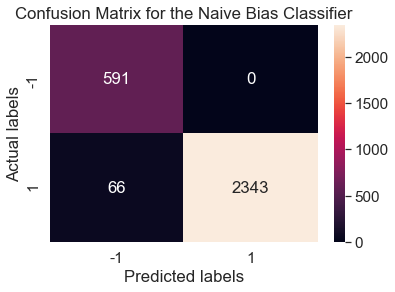

In [25]:
ax= plt.subplot()
sns.heatmap(confusion_matrix(y_test, pred_nb), annot=True, ax = ax, fmt='g')

# labels, title and ticks
ax.set(title='Confusion Matrix for the Naive Bias Classifier', xlabel='Predicted labels', ylabel='Actual labels')
ax.xaxis.set_ticklabels(['-1', '1']); ax.yaxis.set_ticklabels(['-1', '1']);

From the confusion matrix we see that our <b>False Positive</b> count is <i>0</i>. That means we haven not misclassified any legitimate emails as spam. We achieved this result as a trade of for <b>False Negative</b> count of our Model, which is <i>66</i>. So basicaly, we have trade off Recall rate of our model a litle for best False Positive Rate.

<h4>Final Model Training (Holdout Testing technique)</h4>
<p>Finally we train our model with the whole dataset (<b>L &#8746; T' &#8746; T</b>) which can be used as the Filter for spam detection</p>

In [26]:
model_nb.fit(X,y)

MultinomialNB(alpha=0.77001, class_prior=None, fit_prior=True)

<h2>Precision-Recall curve analysis</h2>
<p>We plot Precision-Recall curve and mark the model's position on the curve (for the selected threshold) for final model performance analysis.</p>

In [27]:
from sklearn import metrics
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB(alpha=0.770010)
model_nb.fit(X_train_union, y_train_union)
pred_nb = model_nb.predict(X_test)

Text(0.5, 1.0, 'Precision-Recall curve of the Naive Bayes model: Average Precision=1.00')

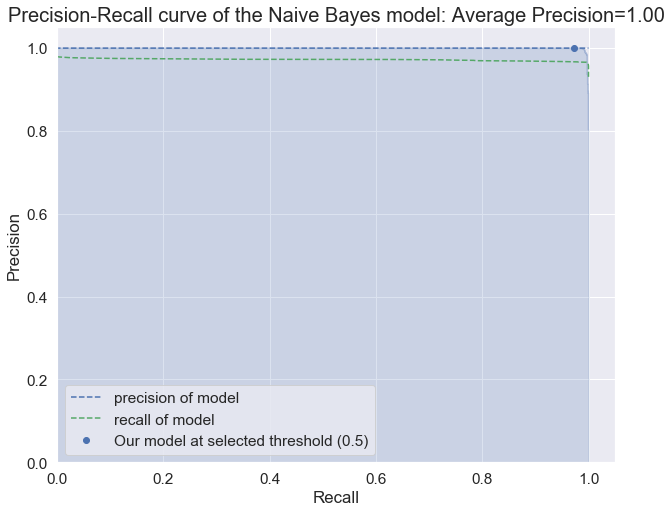

In [29]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(10,8))

y_score_nb = model_nb.predict_proba(X_test)[:,-1]
precision, recall, threshold = precision_recall_curve(y_test, y_score_nb)

average_precision = metrics.average_precision_score(y_test, y_score_nb)

plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.plot(threshold, precision[:-1], 'b--', label='precision of model')
plt.plot(threshold, recall[:-1], 'g--', label = 'recall of model')

#Plot our model position in the graph
plt.plot(recall_score(y_test, pred_nb), precision_score(y_test, pred_nb), 'bo', label='Our model at selected threshold (0.5)')

plt.legend(loc='lower left')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.05])
plt.title('Precision-Recall curve of the Naive Bayes model: Average Precision={0:0.2f}'.format(average_precision), fontsize=20)

<p>as we see from the plot above the whole area is under the curve, which is a nice indicator of our model. Also, our model lies at the outmost edge of curve represented by dotted line.</p>